In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

In [5]:
classes = os.listdir(TRAIN_DIR)
print(f'classes - {len(classes)}\n')
for cls in classes:
    print(cls)

classes - 38

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___healthy
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [6]:
len(classes)

38

In [7]:
image_counts = {}

for cls in classes:
    class_path = os.path.join(TRAIN_DIR,cls)
    image_counts[cls] = len(os.listdir(class_path))

print('\n images per class \n')

for cls, count in image_counts.items():
    print(f'{cls:50} {count}')


 images per class 

Apple___Apple_scab                                 2016
Apple___Black_rot                                  1987
Apple___Cedar_apple_rust                           1760
Apple___healthy                                    2008
Blueberry___healthy                                1816
Cherry_(including_sour)___healthy                  1826
Cherry_(including_sour)___Powdery_mildew           1683
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 1642
Corn_(maize)___Common_rust_                        1907
Corn_(maize)___healthy                             1859
Corn_(maize)___Northern_Leaf_Blight                1908
Grape___Black_rot                                  1888
Grape___Esca_(Black_Measles)                       1920
Grape___healthy                                    1692
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         1722
Orange___Haunglongbing_(Citrus_greening)           2010
Peach___Bacterial_spot                             1838
Peach___healthy            

Text(0, 0.5, 'number of images per class')

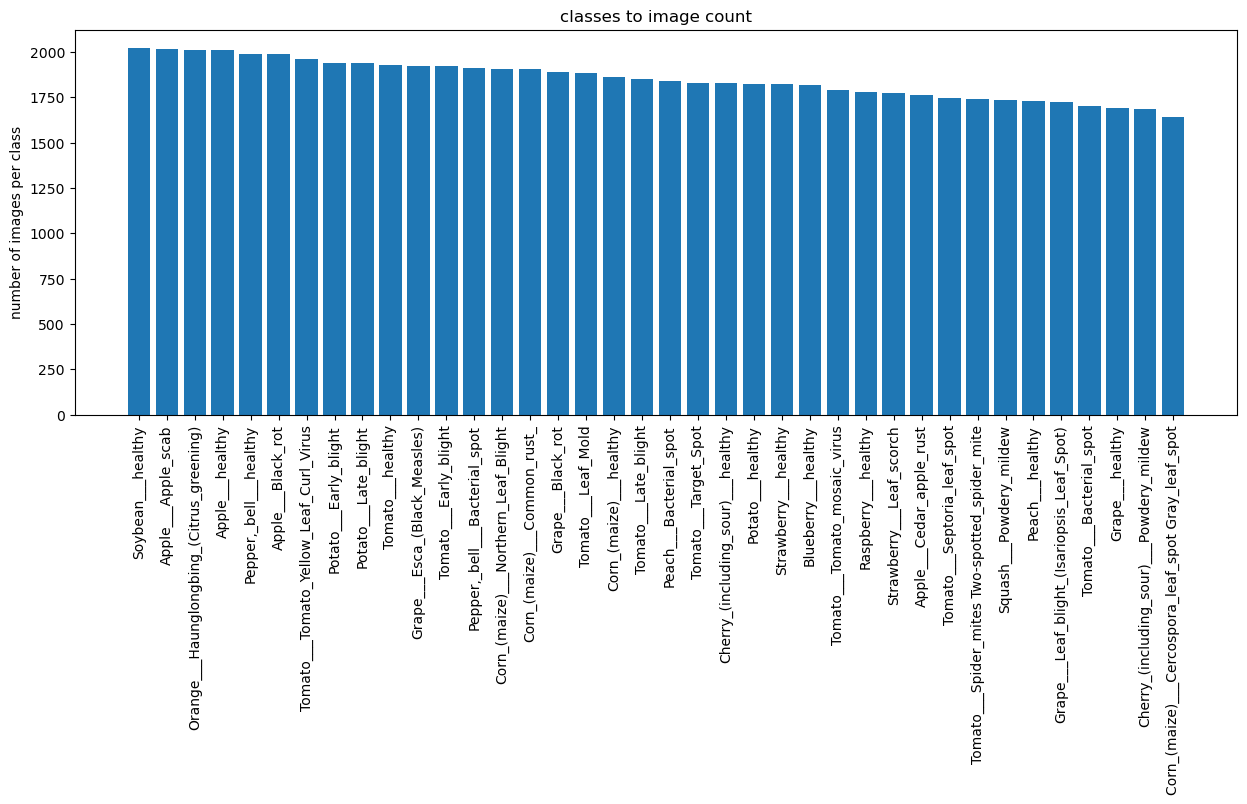

In [26]:
plt.figure(figsize=(15,5))
image_counts = dict(sorted(image_counts.items(),key=lambda x: x[1] ,reverse=True))
plt.bar(image_counts.keys(), image_counts.values())
plt.title("classes to image count")
plt.xticks(rotation=90)
plt.ylabel('number of images per class')

In [11]:
img.shape

(256, 256, 3)

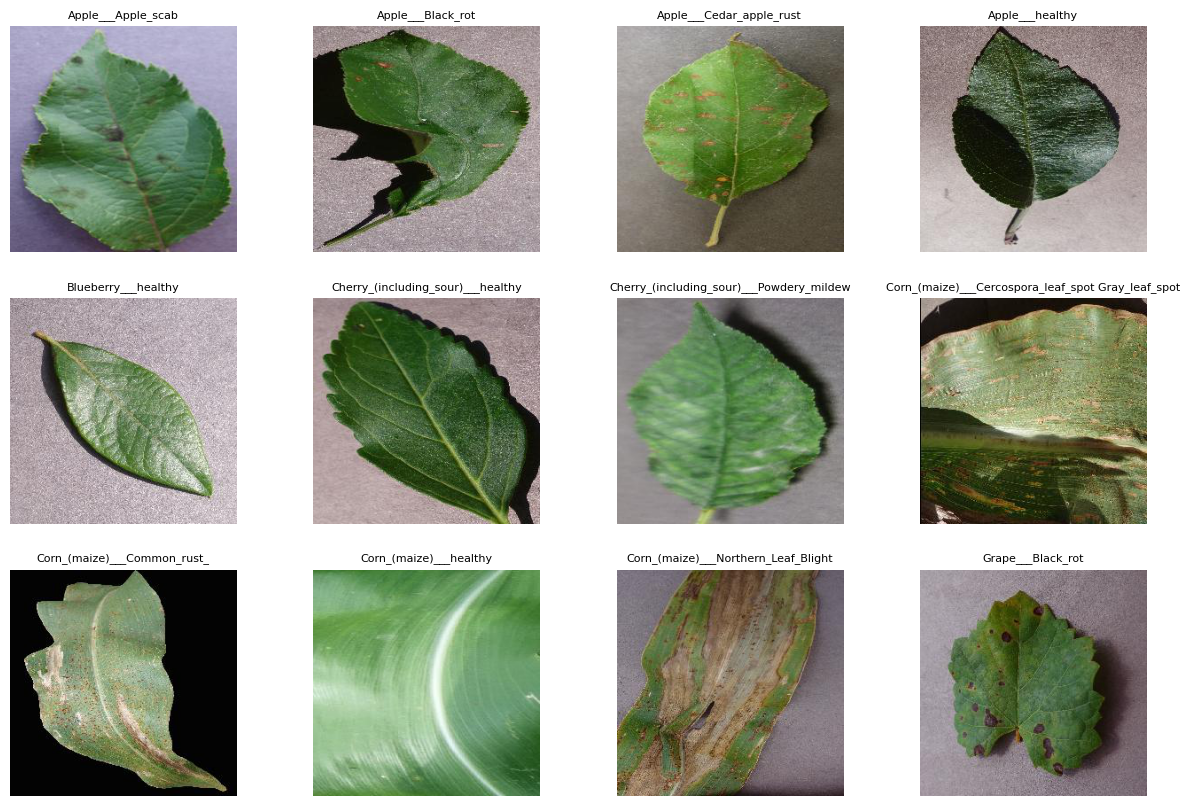

In [10]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:12]):
    image_name = os.listdir(os.path.join(TRAIN_DIR, cls))[0]
    image_path = os.path.join(TRAIN_DIR, cls, image_name)

    img = plt.imread(image_path)
    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(cls, fontsize=8)
    plt.axis('off')


In [12]:
from PIL import Image

In [13]:
image_name = os.listdir(os.path.join(TRAIN_DIR,classes[0]))[0]

image_ = Image.open(os.path.join(TRAIN_DIR, classes[0], image_name))
print(image_.mode, image_.size, type(image_))

RGB (256, 256) <class 'PIL.JpegImagePlugin.JpegImageFile'>


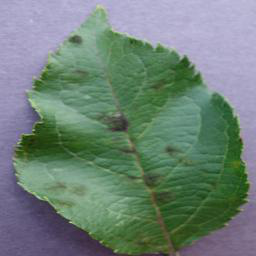

In [14]:
image_

In [15]:
train_total = sum(
    len(os.listdir( os.path.join(TRAIN_DIR,c))) for c in classes
)
print(f"total train images : {train_total}")

total train images : 70295


In [16]:
valid_classes = os.listdir(VALID_DIR)
valid_image_counts = {}

for cls in valid_classes:
    cls_dir_path = os.path.join(VALID_DIR, cls)
    valid_image_counts[cls] = len(os.listdir(cls_dir_path))

for cls, count in valid_image_counts.items():
    print(f'{cls:50} {count}')

Apple___Apple_scab                                 504
Apple___Black_rot                                  497
Apple___Cedar_apple_rust                           440
Apple___healthy                                    502
Blueberry___healthy                                454
Cherry_(including_sour)___healthy                  456
Cherry_(including_sour)___Powdery_mildew           421
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 410
Corn_(maize)___Common_rust_                        477
Corn_(maize)___healthy                             465
Corn_(maize)___Northern_Leaf_Blight                477
Grape___Black_rot                                  472
Grape___Esca_(Black_Measles)                       480
Grape___healthy                                    423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         430
Orange___Haunglongbing_(Citrus_greening)           503
Peach___Bacterial_spot                             459
Peach___healthy                                    432
Pepper,_be

In [17]:
valid_total = sum(
    len(os.listdir( os.path.join(VALID_DIR,c))) for c in classes
)
print(f"total valid images : {valid_total}")

total valid images : 17572


In [18]:
len(valid_classes)

38

Text(0, 0.5, 'number of images per class')

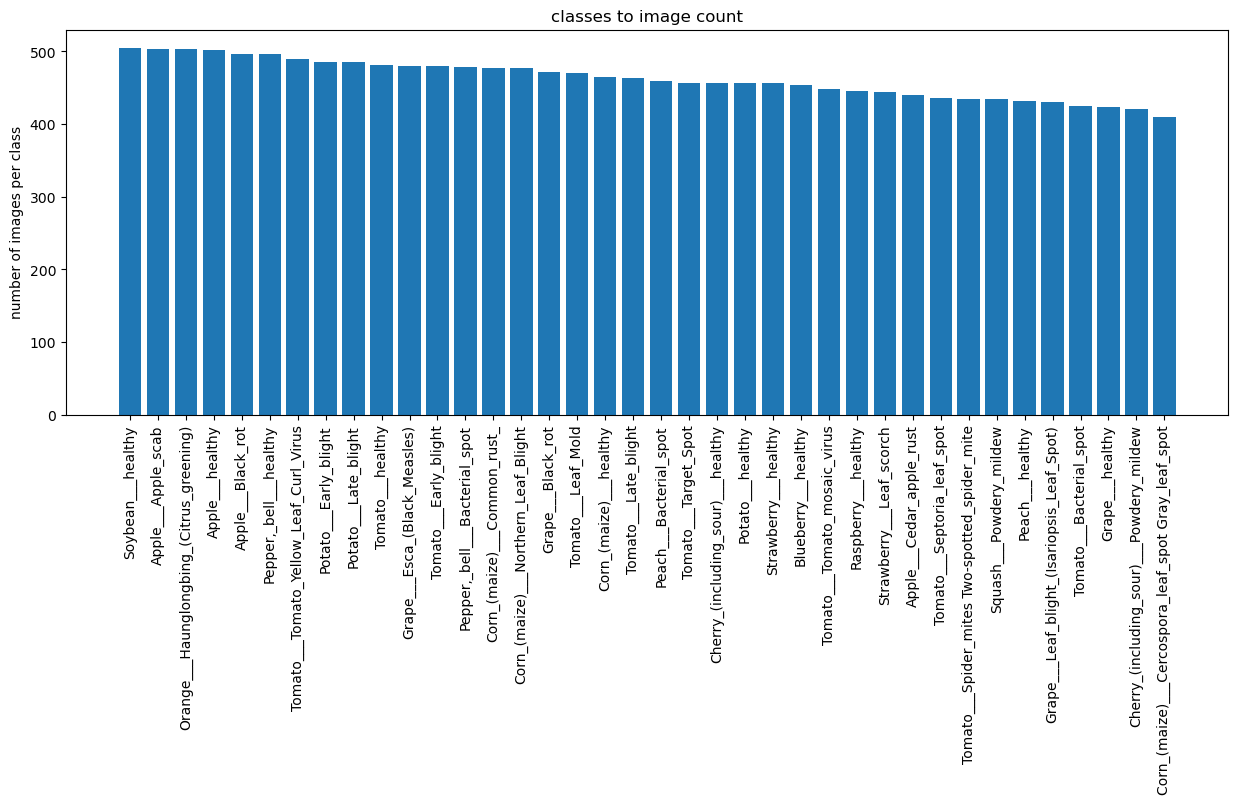

In [21]:
plt.figure(figsize=(15,5))
valid_image_counts = dict(sorted(valid_image_counts.items(),key=lambda x: x[1] ,reverse=True))
plt.bar(valid_image_counts.keys(), valid_image_counts.values())
plt.title("classes to image count")
plt.xticks(rotation=90)
plt.ylabel('number of images per class')

In [22]:
test_total = len(os.listdir( os.path.join(TEST_DIR,'test')))
print(f"total test images : {test_total}")

total test images : 33
